In [60]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display
sns.set_context("paper")
sns.set_style("ticks");
colors = sns.color_palette()

# Data Generation
np.random.seed(1234)
n_true = 1.27 # true polytropic exponent
N = 20 # number of data points
V = np.linspace(1,2,num=N) # volumes, m^3
p1 = 150 # true initial pressure, kPa
c_true = p1*V[0]**n_true # right-hand side coefficient
p_true = c_true/V**n_true # true pressures, kPa
pMeas = p_true + 5*np.random.standard_normal(N) # noisy pressure measurements, kPa

## Polytropic Process
We know that a certain gas undergoes a polytropic process, given by the equation:

$$
p = \frac{c}{V^n}
$$

where $p$ is the pressure, $c$ is a constant, $V$ is the volume, and $n$ is the polytropic exponent.
Imagine that we don't know that value of $n$. 
We can find $n$ by taking measurements of $p$ at different values of $V$ and seeing their relationship. Unfortunately, our measurements have some noise, so we cannot see the true relationship. 


## Question 1:Manual Model Calibration
First, let's try to find $n$ by manually exploring different values of $n$ and seeing how well each value fits the data.

In [56]:
# Interactive Exploration: Try to find the best n manually!

def plot_polytropic_fit(n_guess):
    """
    Plot the polytropic model with a given exponent n
    """
    # For a given n, we need to estimate c from the data
    # Using the first data point: c ≈ p1 * V1^n
    c_guess = pMeas[0] * V[0]**n_guess
    
    # Calculate model predictions
    p_model = c_guess / V**n_guess
    
    # Calculate goodness of fit (mean squared error)
    mse = np.mean((pMeas - p_model)**2)
    
    # Create the plot
    plt.figure(figsize=(10, 6))
    plt.plot(V, pMeas, 'o', color=colors[1], markersize=8, alpha=0.7, label='Measured data')
    plt.plot(V, p_model, '-', color=colors[0], linewidth=3, label=f'Your model (n = {n_guess:.2f})')
    # plt.plot(V, p_true, '--', color=colors[2], linewidth=2, alpha=0.8, label='True relationship (hidden)')
    
    plt.xlabel('Volume (m³)')
    plt.ylabel('Pressure (kPa)')
    plt.title(rf'Polytropic Process: $p = c/V^n$')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Add text box with fit quality
    textstr = f'Mean Squared Error: {mse:.1f}\nLower MSE = Better Fit'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    plt.text(0.02, 0.98, textstr, transform=plt.gca().transAxes, fontsize=10,
             verticalalignment='top', bbox=props)
    
    plt.tight_layout()
    plt.show()
    
    return mse

# Create interactive slider
n_slider = widgets.FloatSlider(
    value=0.5,  # Starting guess (intentionally not the true value)
    min=0.0,
    max=2.0,
    step=0.01,
    description='Exponent n:',
    style={'description_width': 'initial'},
    continuous_update=False  # Only update when slider is released
)

# Create interactive widget
interactive_plot = widgets.interactive(plot_polytropic_fit, n_guess=n_slider)
display(interactive_plot)

interactive(children=(FloatSlider(value=0.5, continuous_update=False, description='Exponent n:', max=2.0, step…

## Question 2: Least Squares Model Calibration
Now, let's see how we can automate this process using least squares regression to find the optimal n mathematically rather than by trial and error. You do not need to do anything with this code, but see how short and simple it is!

Least squares result: n = 1.290
True value:           n = 1.270


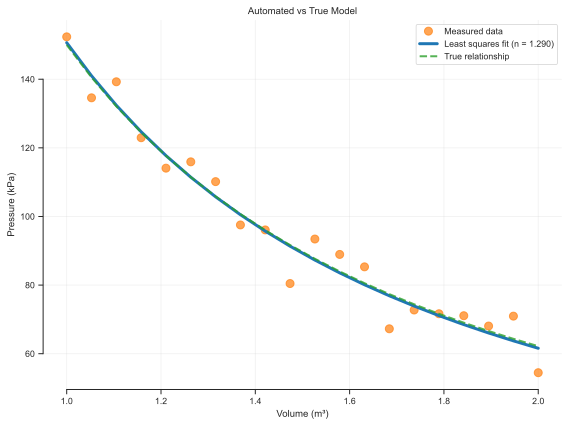

In [62]:
# Automated Parameter Estimation using Least Squares

# The polytropic relationship is: p*V^n = c
# Taking logarithms: log(p) = log(c) - n*log(V)
# This is linear in log space: y = a + b*x, where:
#   y = log(p), x = log(V), a = log(c), b = -n

# Simple least squares solution

# Prepare data for linear regression
y = np.log(pMeas.reshape(-1,1))  # log(pressure) - target variable
x = np.log(V.reshape(-1,1))      # log(volume) - feature variable
X = np.concatenate([np.ones((N,1)), x], axis=1)  # design matrix [1, log(V)]

# Solve normal equations: β = (X^T X)^(-1) X^T y
betaHat = np.linalg.solve(X.T@X, X.T@y)
log_c_hat = betaHat[0]  # intercept = log(c)
n_hat = -betaHat[1]     # slope = -n, so n = -slope
c_hat = np.exp(log_c_hat)

print(f"Least squares result: n = {n_hat[0]:.3f}")
print(f"True value:           n = {n_true:.3f}")

# Calculate final model predictions
p_model_optimal = c_hat / V**n_hat

# Simple comparison plot
plt.figure(figsize=(8, 6))
plt.plot(V, pMeas, 'o', color=colors[1], markersize=8, alpha=0.7, label='Measured data')
plt.plot(V, p_model_optimal, '-', color=colors[0], linewidth=3, label=f'Least squares fit (n = {n_hat[0]:.3f})')
plt.plot(V, p_true, '--', color=colors[2], linewidth=2, alpha=0.8, label=f'True relationship')
plt.xlabel('Volume (m³)')
plt.ylabel('Pressure (kPa)')
plt.title('Automated vs True Model')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
sns.despine(trim=True)
plt.show()


## Question 3: Compare Your Results

Now let's compare the percent error between your manual exploration vs the least squares fit.
Replace the `manual_n` and `lstsq_n` variables with your best results from the manual exploration and the least squares fit above.

In [ ]:
manual_n = 1.00     # Replace this with your slider result!
lstsq_n = 1.00      # Replace this with the least squares result above!

def calculate_percent_error(estimated_n, true_n):
    """
    Calculate percent error between estimated and true values
    """
    percent_error = abs(estimated_n - true_n) / true_n * 100
    return percent_error

# Run the above function to get the percent error for each method
manual_error = calculate_percent_error(manual_n, n_true)
auto_error = calculate_percent_error(lstsq_n, n_true)

# Print the results
print("Percent Error Comparison:")
print(f"\tManual exploration error:\t{manual_error:.2f}%")
print(f"\tLeast squares error:\t\t{auto_error:.2f}%")



Percent Error Comparison:
	Manual exploration error:	21.26%
	Least squares error:		21.26%


## Conclusions:
- The least squares method is a powerful tool for parameter estimation, faster and more accurate than manual exploration.
- Even with the least squares method, we cannot recover the true value of n due to the noise in the data.